<a href="https://colab.research.google.com/github/denjcodes/AAA-501-Group-3/blob/main/notebooks/GroupProjectNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI-520-01 Group 1 Project

## Team Members
- Mohammad Alhabli (malhabli@sandiego.edu)<br>
- Carrie Little (clittle@sandiego.edu)<br>
- Tony Diehl Verdugo (rdiehlverdugo@sandiego.edu
)<br>

# Stock Price Sentiment Analyzer: Linking News Headlines to Market Movements


## Objective


## 1.0. Setup and Imports

In [1]:
# Setup (optional installs for fresh Colab sessions)
# Run if transformers or kagglehub are not already available.
#!pip -q install yfinance transformers ipywidgets kagglehub duckdb beautifulsoup4 requests feedparser
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
#@title Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf  # Yahoo Finance API for stock data (no access reqs)
import requests  # For NewsAPI calls, requires API key (free)

from google.colab import userdata # in order to use Google Secrets to hide and callout individual API keys
import kagglehub
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

## 2.0. Dataset Collection

1. Historical stock prices via Yahoo Finance (yfinance)
1. Financial news via NewsAPI [https://newsapi.org/]
1. Pre-labeled financial sentiment dataset (Kaggle Financial PhraseBank)

In [3]:
#@title 2.1. Download historical stock data from Yahoo Finanace (yfinance)

# From Yahoo Finanace (yfinance) imported above as "yf"
# no access username, password, or api needed

# Prompt to get ticker and time period input from user
stock_ticker = input("Enter the stock ticker symbol (e.g., AAPL): ")
data_period = input("Enter the data period (e.g., 5y, 1y, 6mo): ")

def get_stock_data(ticker: str, period: str = "5y") -> pd.DataFrame:
    """
    Retrieve historical stock data from Yahoo Finance.

    Parameters
    ----------
    ticker : str
        Stock ticker symbol, e.g., 'AAPL'.
    period : str, optional
        Time period for data, default is '5y' (5 years).

    Returns
    -------
    pd.DataFrame
        DataFrame containing historical stock prices.
    """
    stock = yf.Ticker(ticker)
    hist = stock.history(period=period)
    return hist.reset_index()

# Create the Ticker object outside the function to access info
stock = yf.Ticker(stock_ticker)

# Stock Call
stock_df = get_stock_data(stock_ticker, period=data_period)


display(stock_df.head())

Enter the stock ticker symbol (e.g., AAPL): AAPL
Enter the data period (e.g., 5y, 1y, 6mo): 6mo


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-04-21 00:00:00-04:00,192.798087,193.326791,189.346528,192.688354,46742500,0.0,0.0
1,2025-04-22 00:00:00-04:00,195.641118,201.097762,195.491490,199.252289,52976400,0.0,0.0
2,2025-04-23 00:00:00-04:00,205.496994,207.492110,202.304810,204.100418,52929200,0.0,0.0
3,2025-04-24 00:00:00-04:00,204.389708,208.320090,202.444472,207.861206,47311000,0.0,0.0
4,2025-04-25 00:00:00-04:00,205.866084,209.237836,205.696501,208.768982,38222300,0.0,0.0


In [4]:
stock_df.shape

(126, 8)

In [5]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          126 non-null    datetime64[ns, America/New_York]
 1   Open          126 non-null    float64                         
 2   High          126 non-null    float64                         
 3   Low           126 non-null    float64                         
 4   Close         126 non-null    float64                         
 5   Volume        126 non-null    int64                           
 6   Dividends     126 non-null    float64                         
 7   Stock Splits  126 non-null    float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 8.0 KB


In [6]:
stock_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,126.000000,126.000000,126.000000,126.000000,1.260000e+02,126.000000,126.0
mean,219.433199,221.621882,217.354650,219.576796,5.377616e+07,0.004127,0.0
std,19.328241,19.367845,19.276655,19.448680,1.959502e+07,0.032626,0.0
min,192.798087,193.326791,189.346528,192.688354,3.062120e+07,0.000000,0.0
25%,203.289290,205.826412,200.867036,202.615055,4.248250e+07,0.000000,0.0
50%,211.195312,213.517680,209.497243,212.129250,4.873165e+07,0.000000,0.0
75%,233.627499,234.877499,230.745003,233.192501,5.622605e+07,0.000000,0.0
max,257.989990,259.239990,256.109985,258.059998,1.637413e+08,0.260000,0.0


In [7]:
#@title Yahoo Finanace (yfinance) - Display ticker and company name, dats period and date range
print(f"Stock Ticker: {stock_ticker}")
print(f"Company Name: {stock.info['longName']}")
print(f"Data Period: {data_period}")
print(f"Date Range: {stock_df['Date'].min().strftime('%Y-%m-%d')} to {stock_df['Date'].max().strftime('%Y-%m-%d')}")

Stock Ticker: AAPL
Company Name: Apple Inc.
Data Period: 6mo
Date Range: 2025-04-21 to 2025-10-17


In [8]:
#@title 2.2. Get financial news via NewsAPI
# uses the stock ticker symbol from the previous cell as input for fetching the news
# need to create free API key at https://newsapi.org/

#NEWSAPI API key is:
NEWS_API_KEY = userdata.get('NEWS_API_KEY')  # Replace 'NEWSAPI_KEY' with your own NewsAPI key - use 'Colab Secrets' (key symbol in left panel)
NEWS_ENDPOINT = "https://newsapi.org/v2/everything"

def get_news(query: str, page_size: int = 50) -> pd.DataFrame:
    """
    Fetch financial news using NewsAPI.

    Parameters
    ----------
    query : str
        Search keyword or ticker symbol.
    page_size : int, optional
        Number of articles per request (max 100).

    Returns
    -------
    pd.DataFrame
        DataFrame containing news headlines and descriptions.
    """
    params = {
        "q": query,
        "apiKey": NEWS_API_KEY,
        "language": "en",
        "pageSize": page_size,
        "sortBy": "relevancy"
    }
    response = requests.get(NEWS_ENDPOINT, params=params)
    articles = response.json().get("articles", [])
    return pd.DataFrame(articles)

news_df = get_news(stock_ticker)

display(news_df.head())

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Yahoo Entertainment'}",Ali Ahmed,Apple (AAPL) Sees High Demand for Affordable i...,Apple Inc. (NASDAQ:AAPL) is one of the 15 Best...,https://finance.yahoo.com/news/apple-aapl-sees...,https://s.yimg.com/ny/api/res/1.2/e1QwhqQiBt5e...,2025-09-26T04:07:06Z,Apple Inc. (NASDAQ:AAPL) is one of the 15 Best...
1,"{'id': None, 'name': 'Yahoo Entertainment'}",Yahoo Finance Video,Apple's new iPhone 17 is available. Will users...,Apple's (AAPL) new iPhone 17 and Apple Watch a...,https://finance.yahoo.com/video/apples-iphone-...,https://s.yimg.com/ny/api/res/1.2/rLaI1JXkGBKm...,2025-09-19T14:28:10Z,Let's turn now to our stock of the day. Apple'...
2,"{'id': None, 'name': 'Yahoo Entertainment'}",Yahoo Finance Video,Intel 'needs' Apple to invest like Nvidia & US...,Intel (INTC) is reportedly working to secure a...,https://finance.yahoo.com/video/intel-needs-ap...,https://s.yimg.com/ny/api/res/1.2/fyHbmadYLa7Z...,2025-09-25T19:30:00Z,I want to ask you about kind of taking a littl...
3,"{'id': None, 'name': 'Barchart.com'}",Elizabeth H. Volk,Nvidia CEO Jensen Huang Says 'You Can’t Overst...,Foundry giant Taiwan Semiconductor will play a...,https://www.barchart.com/story/news/34900133/n...,https://s.yimg.com/ny/api/res/1.2/aHKlvg5I5WHR...,2025-09-18T19:02:02Z,"At a press conference today, Nvidia (NVDA) CEO..."
4,"{'id': None, 'name': 'Yahoo Entertainment'}",Yahoo Finance,Trump tariffs live updates: White House nears ...,Yahoo Finance is chronicling the latest news a...,https://finance.yahoo.com/news/live/trump-tari...,https://s.yimg.com/ny/api/res/1.2/DilOGwckrxDV...,2025-10-10T16:24:18Z,President Trump on Wednesday confirmed that tr...


In [9]:
news_df.shape

(50, 8)

In [10]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   source       50 non-null     object
 1   author       46 non-null     object
 2   title        50 non-null     object
 3   description  46 non-null     object
 4   url          50 non-null     object
 5   urlToImage   46 non-null     object
 6   publishedAt  50 non-null     object
 7   content      50 non-null     object
dtypes: object(8)
memory usage: 3.3+ KB


In [11]:
news_df.describe()

,source,author,title,description,url,urlToImage,publishedAt,content
count,50,46,50,46,50,46,50,50
unique,8,28,50,46,50,40,50,47
top,"{'id': None, 'name': 'Yahoo Entertainment'}",Ghazal Ahmed,Apple (AAPL) Sees High Demand for Affordable i...,Apple Inc. (NASDAQ:AAPL) is one of the 15 Best...,https://finance.yahoo.com/news/apple-aapl-sees...,https://s.yimg.com/ny/api/res/1.2/e1QwhqQiBt5e...,2025-09-26T04:07:06Z,"If you click 'Accept all', we and our partners..."
freq,38,8,1,1,1,2,1,4


In [12]:
#@title NewsAPI - Display ticker and company name
print(f"Stock Ticker: {stock_ticker}")
print(f"Company Name: {stock.info['longName']}")

Stock Ticker: AAPL
Company Name: Apple Inc.


In [13]:
#@title 2.3. Load Kaggle Financial PhraseBank dataset
# https://www.kaggle.com/datasets/yogeshchary/financial-news-dataset
# raw datafile also located in GitHub `/data/raw/financial_phrasebank.csv`

# Download latest version from Kaggle
path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")

# Display path to dataset files
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'financial-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/financial-sentiment-analysis


In [14]:
# List downloaded files in directory path
!ls /kaggle/input/financial-sentiment-analysis

data.csv


In [15]:
phrase_df = pd.read_csv("/kaggle/input/financial-sentiment-analysis/data.csv")
display(phrase_df.head())

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [16]:
# List downloaded files in directory path
!ls /kaggle/input/financial-sentiment-analysis

data.csv


In [17]:
phrase_df = pd.read_csv("/kaggle/input/financial-sentiment-analysis/data.csv")
display(phrase_df.head())

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [18]:
phrase_df.shape

(5842, 2)

In [19]:
phrase_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [20]:
phrase_df.describe()

,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,"Operating loss totalled EUR 0.9 mn , down from...",neutral
freq,2,3130


## 3.0. Data Preprocessing

1. Clean text (remove punctuation, lowercasing, stopwords)
1. Tokenize text and apply TF-IDF
1. Prepare labels (from Kaggle Financial PhraseBank)

### 3.1.  Clean text (remove punctuation, lowercasing, stopwords)

In [21]:
#@title Stopword set
STOPWORDS = ENGLISH_STOP_WORDS

def clean_text(text_str: str) -> str:
    """
    Clean input text string by removing punctuation, digits, and stopwords.

    Parameters
    ----------
    text_str : str
        Input text string.

    Returns
    -------
    str
        Cleaned and processed text string.
    """
    # Lowercase
    text_str = text_str.lower()
    # Remove non-alphabetic characters
    text_str = re.sub(r"[^a-z\s]", "", text_str)
    # Remove stopwords
    tokens = [word for word in text_str.split() if word not in STOPWORDS]
    return " ".join(tokens)

# Example usage
# cleaned = clean_text("Apple beats earnings expectations for Q4!")
# print(cleaned)

In [22]:
#@title Clean text
phrase_df["clean_text"] = phrase_df["Sentence"].apply(clean_text)
phrase_df.head()

,Sentence,Sentiment,clean_text
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon s gps...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi lows bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",positive,quarter componenta s net sales doubled eurm eu...
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...


In [23]:
#@title Encode labels
label_map = {"positive": 1, "negative": -1, "neutral": 0}
phrase_df["label_encoded"] = phrase_df["Sentiment"].map(label_map)
phrase_df.head()

,Sentence,Sentiment,clean_text,label_encoded
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon s gps...,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi lows bk real possibility,-1
2,"For the last quarter of 2010 , Componenta 's n...",positive,quarter componenta s net sales doubled eurm eu...,1
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...,0
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...,0


In [24]:
#@title Save processed data to CSV
# Save the processed DataFrame
phrase_df.to_csv(f"financial_phrasebank_processed.csv", index=False)


In [25]:
#@title Load processed data from CSV
processed_phrase_df = pd.read_csv("financial_phrasebank_processed.csv")
display(processed_phrase_df.head())

,Sentence,Sentiment,clean_text,label_encoded
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon s gps...,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi lows bk real possibility,-1
2,"For the last quarter of 2010 , Componenta 's n...",positive,quarter componenta s net sales doubled eurm eu...,1
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...,0
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...,0


In [26]:
#@title  Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    phrase_df["clean_text"], phrase_df["label_encoded"], test_size=0.2, random_state=42
)


# 4.0 Vectorization
---



To prepare for classification, we need to convert the preprocessed financial news text into numerical features so the model is able to understand the data, we achieve this with two common vectorization methods:

- Bag of Words (BoW): Captures word frequency, more simply, how many times a word occurs in a document/text. This does not pay attention to the order of a term in a sentence and only notices the frequency of it.

- TF-IDF (Term Frequency–Inverse Document Frequency): Captures word importance by calculating how often this word occurs in the overall text, the less common the word, the more importance and value it is given. It also reduces the importance weight of common words.

In [27]:
# initializing the vectorizers, also removing stop words and only keep the most common 5k words
bow_vectorizer = CountVectorizer(stop_words="english", max_features=5000)
# for this max_features, keep the 5k highest ranked worsd by TD-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

# train and test transforming the train and test sets
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# print shapes
print("Bag of Words Training set shape:", X_train_bow.shape)
print("Bag of Words Test set shape:", X_test_bow.shape)
print("TF-IDF Training set shape:", X_train_tfidf.shape)
print("TF-IDF Test set shape:", X_test_tfidf.shape)

# samples of features
print("\nBag of Words feature samples:")
print(bow_vectorizer.get_feature_names_out()[:5])
print("\nTF-IDF feature samples:")
print(tfidf_vectorizer.get_feature_names_out()[:5])


Bag of Words Training set shape: (4673, 5000)
Bag of Words Test set shape: (1169, 5000)
TF-IDF Training set shape: (4673, 5000)
TF-IDF Test set shape: (1169, 5000)

Bag of Words feature samples:
['aaland' 'aapl' 'aazhang' 'ab' 'abandons']

TF-IDF feature samples:
['aaland' 'aapl' 'aazhang' 'ab' 'abandons']


# 5.0 Baseline Model
---


This section was originally used to evaluate Bag-of-Words and TF-IDF vectorizations with Logistic Regression.

It provides a useful performance benchmark (~70% accuracy), but we ultimately transitioned to a language-model-driven approach for alignment with agentic AI principles. The final system uses an LLM as a zero-shot classifier.

We will use a Logistic Regression model as our baseline model. It is a simple enough model for us to interpret how well the raw text features we got from the vectoriziation methods perform on a model.

## 5.1 Model Training

In [28]:
from sklearn.linear_model import LogisticRegression

# func to train on both vectorization methods
def train(X_train, y_train):
    model = LogisticRegression(max_iter=1000) # init model
    model.fit(X_train, y_train) # fit the data
    return model

bow_LR_model = train(X_train_bow, y_train)
tfidf_LR_model = train(X_train_tfidf, y_train)

## 5.2 Model Evaluation

In [29]:
from sklearn.metrics import accuracy_score, classification_report

# func to evaluate on both vectorization methods
def evaluate(model, X_test, y_test, model_name): # model_name to print out model names
    y_pred = model.predict(X_test) # predict
    accuracy = accuracy_score(y_test, y_pred) # metrics
    report = classification_report(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy}\n")
    print(f"{model_name} Classification Report:\n{report}")


evaluate(bow_LR_model, X_test_bow, y_test, "Bag of Words")
print("\n")
evaluate(tfidf_LR_model, X_test_tfidf, y_test, "TF-IDF")

Bag of Words Accuracy: 0.6911890504704876

Bag of Words Classification Report:
              precision    recall  f1-score   support

          -1       0.32      0.22      0.26       175
           0       0.72      0.81      0.76       622
           1       0.77      0.71      0.74       372

    accuracy                           0.69      1169
   macro avg       0.60      0.58      0.59      1169
weighted avg       0.67      0.69      0.68      1169



TF-IDF Accuracy: 0.7005988023952096

TF-IDF Classification Report:
              precision    recall  f1-score   support

          -1       0.48      0.16      0.24       175
           0       0.70      0.89      0.78       622
           1       0.75      0.64      0.69       372

    accuracy                           0.70      1169
   macro avg       0.64      0.56      0.57      1169
weighted avg       0.68      0.70      0.67      1169



# 6.0 LLM-Based Classification (Final Method)

## 6.1 Batch Classification using LLMs

In this section, we use a pre-trained language model to classify financial news headlines into positive, neutral, or negative sentiment without any training otherwise known as zero-shot classification. This method allows a model to make predictions on tasks it wasn’t explicitly trained for, simply by providing it with a list of candidate labels. Although we’re not training a model from scratch here, we still use preprocessed data to make sure we have clean, meaningful input. This helps improve the reliability of the model’s predictions.

We used the `MoritzLaurer/deberta-v3-base-zeroshot-v1` model, a DeBERTa-based architecture that is known for its strong performance and efficiency. We chose this model over larger alternatives like BART to reduce loading times due to it being a lightweight model and be better suited for agent-based workflows. We chose this model for the first iteration so we have quick and flexible way to able to observe and evaluate how well an LLM can classify financial sentiment out of the box. It provides us with a useful benchmark. Based on the results, we plan to explore improvements such as fine-tuning on labeled financial data, refining prompts, or comparing alternative models. This iterative approach reflects the core principles of agentic AI: adapting and improving over time.

In [30]:
from transformers import pipeline

# import deberta model zeroshot pipeline from HF
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-base-zeroshot-v1")

# function so we can classify texts with the LLM
def llm_batch_classifier(texts, labels=["positive", "neutral", "negative"]):
    preds = [] # store predictions
    for text in texts:
      # pass each text in the classifier with candidate_labels since its the standard zero-shot classifier
      result = classifier(text, candidate_labels=labels)
      preds.append(result['labels'][0]) # append the highest ranking label
    return preds # return the list

# take 100 preprocessed headlines from the test set so we dont spend a lot of time since LLMs take a long time on big data batches
preprocessed_sample = X_test.iloc[:100].tolist()
llm_predictions = llm_batch_classifier(preprocessed_sample)# predict on the sample headlines

# print first 10 predicitons with the text
for i, (text, prediction) in enumerate(zip(preprocessed_sample[:10], llm_predictions[:10])):
    print(f"Text Sample no.{i + 1}: {text[:100]}") # trunicate so it doesn't show the full headline
    print(f"Sentiment: {prediction}\n") # print senitment


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Text Sample no.1: employees remain oulu plant support functions group units
Sentiment: neutral

Text Sample no.2: comparable net sales expected increase line group target
Sentiment: positive

Text Sample no.3: tesla recalling model x cars httpstcozbkvstl tsla
Sentiment: negative

Text Sample no.4: finnish software developer solutions oyj said net profit increased mln euro mln mln euro mln
Sentiment: positive

Text Sample no.5: compagnie financement foncier issue benchmark year covered deal euros
Sentiment: neutral

Text Sample no.6: works include laying natural stone pavements installation underground heating surface water drainage
Sentiment: neutral

Text Sample no.7: peer peugeot fell pct sales rose pct period year
Sentiment: negative

Text Sample no.8: memorandum understanding cooperation finnish global chemical company kemira vietnam national chemica
Sentiment: positive

Text Sample no.9: vaisala group successful international technology company develops manufactures markets electr

## 6.2 LLM Model Evaluation

In [31]:
label_map = {"positive": 1, "negative": -1, "neutral": 0} # map labels
# convert predictions labels from strings to numeric values using the map
y_pred_llm = [label_map[pred] for pred in llm_predictions]
# get the true labels of the same 100 headlines we used for the sample for comparison
y_true_llm = y_test.iloc[:100].tolist()
print("Classification report:")
print(classification_report(y_true_llm, y_pred_llm, target_names=["Negative", "Neutral", "Positive"]))

Classification report:
              precision    recall  f1-score   support

    Negative       0.43      0.69      0.53        13
     Neutral       0.81      0.75      0.78        51
    Positive       0.81      0.72      0.76        36

    accuracy                           0.73       100
   macro avg       0.68      0.72      0.69       100
weighted avg       0.76      0.73      0.74       100



# 7.0 Agent System Workflow

## 7.1.1 News Sentiment Agent

This agent pulls recent news headlines for a given stock ticker using NewsAPI, then classifies each headline's sentiment. This allows the system to detect how the market is reacting to company-specific news without requiring labeled data or retraining.

In [32]:
import requests
from datetime import datetime, timedelta
import pandas as pd
# get recent news for the ticker, over the last 7 days, maxiumum of 20 texts
def news_sentiment(ticker, period="7d", max_articles=20):
    api_key = userdata.get('NEWS_API_KEY') # get api

    query = f"{ticker} stock" # set up the query

    def period_to_days(p): # convert period to days since newsapi only accepts days
        if p.endswith("mo"):
            return int(p[:-2]) * 30
        if p.endswith("y"):
            return int(p[:-1]) * 365
        if p.endswith("d"):
            return int(p[:-1])
        return 7 # default to 7 days
    # start the time of the search for news
    days = period_to_days(period)
    from_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')
    # url for the api
    url = "https://newsapi.org/v2/everything"

    # combine parameters
    params = {
        "q": query,
        "from": from_date,
        "sortBy": "relevancy",
        "language": "en",
        "pageSize": max_articles,
        "apiKey": api_key
    }

    # send the response to get the url and text
    response = requests.get(url, params=params)
    articles = response.json().get("articles", [])
    # get the headline
    headlines = [article["title"] for article in articles if article.get("title")]
    # classifiy using the LLMs
    sentiments = llm_batch_classifier(headlines)
    # add the sentiments and the headlines together
    results = list(zip(headlines, sentiments))
    return results

## 7.1.2 Testing the News Sentiment Agent

In [33]:
ticker = "AAPL"
sentiment_results = news_sentiment(ticker)

for i, (headline, sentiment) in enumerate(sentiment_results[:5]):
    print(f"{i+1}. {headline}\n   → Sentiment: {sentiment}\n")

1. Buy Or Sell Apple Stock?
   → Sentiment: neutral

2. AMZN Stock vs. MSFT Stock
   → Sentiment: neutral

3. Analyst Says Apple (AAPL) Foldable Phone Won’t ‘Move The Needle’
   → Sentiment: neutral

4. Global markets tumble as Beijing imposes new ban on U.S. shipping and Bessent vows China ‘will be hurt the most’ if it doesn’t surrender
   → Sentiment: negative

5. Apple (AAPL) Stock Faces “More Downside Than Upside” as Jefferies Flags Tariff Concerns
   → Sentiment: negative



## 7.2.1 Market Analyzer Agent

This agent retrieves recent price data for a given stock ticker using the yfinance API. It calculates basic performance indicators such as daily percent changes, average return, and volatility. These insights will later be used to compare market behavior to news sentiment.

In [34]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

#get latest stock price data by using yfinance library and analyzes the trend into summaries.
def market_analyzer(ticker, period="7d"):

    def period_to_days(p):
        if p.endswith("mo"):
            return int(p[:-2]) * 30
        if p.endswith("y"):
            return int(p[:-1]) * 365
        if p.endswith("d"):
            return int(p[:-1])
        return 7
    days = period_to_days(period)
    end_date = datetime.today() # determine dates
    start_date = end_date - timedelta(days=days)
    # download the data between the dates
    df = yf.download(ticker, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), auto_adjust=False)
    df["Daily % Change"] = df["Close"].pct_change() * 100 # daily percent

    # get average return, votaliatity, last closing price and the direction where it might go
    avg_return = df["Daily % Change"].mean()
    volatility = df["Daily % Change"].std()
    latest_price_val = df["Close"].iloc[-1]
    if isinstance(latest_price_val, pd.Series):
      latest_price_val = latest_price_val.iloc[0]
    latest_price = float(latest_price_val)
    price_direction = "up" if avg_return > 0 else "down" if avg_return < 0 else "flat"

# return results
    return {
        "ticker": ticker,
        "days_analyzed": days,
        "avg_daily_return": round(avg_return, 2),
        "volatility": round(volatility, 2),
        "latest_price": round(latest_price, 2),
        "trend": price_direction
    }

## 7.2.2 Testing the Market Analyzer Agent

In [35]:
ticker = "AAPL"
market_summary = market_analyzer(ticker)

print("Market Summary:\n")
for k, v in market_summary.items():
    print(f"{k}: {v}")

[*********************100%***********************]  1 of 1 completed

Market Summary:

ticker: AAPL
days_analyzed: 7
avg_daily_return: 0.47
volatility: 1.14
latest_price: 252.29
trend: up


## 7.3.1 Evaluation Agent



This agent compares the overall sentiment of recent news headlines with the recent market trend for a given stock. If the sentiment and market behavior align (e.g., positive news and rising stock), the agent reports consistency. If they contradict, the agent flags a potential mismatch and suggests further investigation.

In [36]:
def evaluator(sentiment_results, market_summary):
    if not sentiment_results or not market_summary: # check if the data exists
        return "Not enough data to evaluate."

    sentiment_count = {"positive": 0, "neutral": 0, "negative": 0} # sentiment hashmap counter
    for _, sentiment in sentiment_results: # for each sentiment in the results
        if sentiment in sentiment_count: # if its in the map
            sentiment_count[sentiment] += 1 # increase the count for label

    # sentiment with the most count
    majority_sentiment = max(sentiment_count, key=sentiment_count.get)

    trend = market_summary["trend"] # trend of the mark if its up or down

    # logic to recommend
    if majority_sentiment == "positive" and trend == "up":
        recommendation = "Buy"
    elif majority_sentiment == "negative" and trend == "down":
        recommendation = "Sell"
    else:
        recommendation = "Hold"

    return {
        "majority_sentiment": majority_sentiment,
        "market_trend": trend,
        "recommendation": recommendation
    }

## 7.3.2 Testing the Evaluator Agent

In [37]:
decision = evaluator(sentiment_results, market_summary)

print("Evaluation:\n")
for k, v in decision.items():
    print(f"{k}: {v}")

Evaluation:

majority_sentiment: positive
market_trend: up
recommendation: Buy


## 7.4.1 Summarizer Agent

This agent combines the outputs of the previous agents into a final summary that is understandable in natural-language. It allows the system to present its findings and recommendation in a clear, human-readable format.

In [38]:
def summarizer(sentiment_results, market_summary, evaluation_result, ticker=""):
    if isinstance(evaluation_result, str):
        return evaluation_result  # handles just in case if there isnt enough data

    # assign each parameter from the evaluator to a variable that we can plug into a summary prompt
    sentiment = evaluation_result["majority_sentiment"]
    trend = evaluation_result["market_trend"]
    recommendation = evaluation_result["recommendation"]
    price = market_summary.get("latest_price", "N/A")

    summary = f"In the past week, the majority of news about {ticker.upper()} has been {sentiment}.\n "
    summary += f"The stock has been trending {trend}, with a current price around ${price}.\n"
    summary += f"Based on the combined sentiment and market data, the system recommends: **{recommendation.upper()}**."

    return summary

## 7.4.2 Testing the Summarizer Agent

In [39]:
summary_print = summarizer(sentiment_results, market_summary, decision, ticker="AAPL")
print("Summary of Chosen Stock:\n")
print(summary_print)

Summary of Chosen Stock:

In the past week, the majority of news about AAPL has been positive.
 The stock has been trending up, with a current price around $252.29.
Based on the combined sentiment and market data, the system recommends: **BUY**.


## 7.5.1 Full Workflow for One Ticker

This section runs the complete agent workflow for a given stock ticker. It pulls news, classifies sentiment, analyzes recent market trends, evaluates consistency between the two, and outputs a human-readable summary and recommendation.

In [40]:
def run_agent(ticker, period="7d"):
  news_sentiment_agent = news_sentiment(ticker, period=period)
  def period_to_days(p):
        if p.endswith("mo"):
            return int(p[:-2]) * 30
        if p.endswith("y"):
            return int(p[:-1]) * 365
        if p.endswith("d"):
            return int(p[:-1])
        return 7

  days = period_to_days(period)
  # combine all agents into one function
  market_analyzer_agent = market_analyzer(ticker, period=period)
  evaluation_agent = evaluator(news_sentiment_agent, market_analyzer_agent)
  summarizer_agent = summarizer(news_sentiment_agent, market_analyzer_agent, evaluation_agent, ticker)

  print(f"\n\nMarket Summary of {ticker}:")
  for k, v in market_analyzer_agent.items():
      print(f"{k}: {v}")

  print(f"\nEvaluation:")
  if isinstance(evaluation_agent, dict):
      for k, v in evaluation_agent.items():
          print(f"{k}: {v}")
  else:
      print(evaluation_agent)

  print(f"\nFinal Summary:")
  print(summarizer_agent)

  payload = {
      "classified_news_df": pd.DataFrame({
            "title": [h for h, _ in news_sentiment_agent],
            "label": [s for _, s in news_sentiment_agent],
            # "score": [1.0] * len(news_sentiment_agent),  # placeholder scores
            "publishedAt": pd.Timestamp.now(),
            "source_name": "NewsAPI",
            "description": None
        }),
        "fundamentals_dict": {
            "pe": None,
            "eps": None,
            "mktcap": None,
            "sector": "Unknown"
        },
        "router_counts": {
            "earnings_news": 0,
            "general_news": len(news_sentiment_agent)
        },
        "draft_brief_v1": summarizer_agent
    }

  return payload

## 7.5.2 Testing Workflow Agent

In [41]:
run_agent("AAPL", period="7d")

[*********************100%***********************]  1 of 1 completed



Market Summary of AAPL:
ticker: AAPL
days_analyzed: 7
avg_daily_return: 0.47
volatility: 1.14
latest_price: 252.29
trend: up

Evaluation:
majority_sentiment: positive
market_trend: up
recommendation: Buy

Final Summary:
In the past week, the majority of news about AAPL has been positive.
 The stock has been trending up, with a current price around $252.29.
Based on the combined sentiment and market data, the system recommends: **BUY**.


{'classified_news_df':                                                 title     label  \
 0                            Buy Or Sell Apple Stock?   neutral   
 1                           AMZN Stock vs. MSFT Stock   neutral   
 2   Analyst Says Apple (AAPL) Foldable Phone Won’t...   neutral   
 3   Global markets tumble as Beijing imposes new b...  negative   
 4   Apple (AAPL) Stock Faces “More Downside Than U...  negative   
 5     Medtronic Stock’s $50 Billion Gift To Investors   neutral   
 6   Options Alert: Iron Condor Screener Results fo...   neutral   
 7   New M5 Chip Comes to iPad Pro, MacBook Pro 14″...   neutral   
 8   Friday’s selloff broke something in the stock ...  negative   
 9    Analyst Explains ‘The Problem’ With Apple (AAPL)  negative   
 10  Stock market today: Dow, S&P 500, Nasdaq futur...  positive   
 11  Apple (AAPL) Price Target Stays at $220 as UBS...  positive   
 12  Wedbush Sees an AI M&A Boom Ahead: 3 Prime Tak...  positive   
 13  Stock market today: D

# 8.0 Evaluator–Optimizer and Memory

### Evaluator–Optimizer

This section closes the loop for our agentic investment research system. Upstream agents produce four artifacts: a labeled news table, a fundamentals dictionary, simple router counts, and an initial analyst brief. The contract normalizer (Section 8.0) standardizes variable names so this section runs even when teammates used different names. The Evaluator (Section 8.1) checks draft length, presence of numbers and dates, jargon, alignment with sentiment, earnings coverage via router counts, and whether valuation data like P/E is referenced. The Optimizer applies targeted edits to fix issues and enforce concise length. Each run appends a short note to `agent_memory.json` and logs metrics to `run_log.csv`, which demonstrates self-reflection and learning across runs. Together with earlier ingestion, preprocessing, classification, and routing, this satisfies Prompt Chaining, Routing, and Evaluator–Optimizer workflows and the agent functions of planning, tool use, self-assessment, and learning across runs.

In [42]:
#@title 8.1. Contract Normalizer
from typing import Any, Optional
import pandas as pd
import numpy as np
import json

def _first_existing(name_candidates: list[str]) -> Optional[Any]:
    for nm in name_candidates:
        if nm in globals():
            return globals()[nm]
    return None

# 1) ticker
ticker = _first_existing(["ticker", "TICKER", "selected_ticker", "ticker_choice", "SYMBOL"]) or "AAPL"
ticker = str(ticker)

# 2) classified_news_df
_news = _first_existing([
    "classified_news_df", "news_classified_df", "df_news_classified", "news_df_classified",
    "news_labeled_df", "news_df_labeled", "news_cleaned_df", "news_df"
])
classified_news_df = _news.copy() if isinstance(_news, pd.DataFrame) else pd.DataFrame()
col_map = {"published_at": "publishedAt", "pub_date": "publishedAt", "datetime": "publishedAt",
           "headline": "title", "summary": "description", "source": "source_name", "confidence": "score"}
if not classified_news_df.empty:
    classified_news_df = classified_news_df.rename(columns={c: col_map.get(c, c) for c in classified_news_df.columns})
required_cols = ["publishedAt", "title", "description", "label", "score", "source_name"]
for c in required_cols:
    if c not in classified_news_df.columns:
        classified_news_df[c] = np.nan
classified_news_df["publishedAt"] = pd.to_datetime(classified_news_df["publishedAt"], errors="coerce")

def _norm_label(x: Any) -> str:
    s = str(x).strip().lower()
    if s in {"pos", "positive", "bull", "bullish", "green"}:
        return "positive"
    if s in {"neg", "negative", "bear", "bearish", "red"}:
        return "negative"
    return "neutral"

def _to_score(x: Any) -> float:
    try:
        v = float(x)
        if np.isnan(v):
            return 0.5
        return max(0.0, min(1.0, v))
    except Exception:
        return 0.5

classified_news_df["label"] = classified_news_df["label"].apply(_norm_label)
classified_news_df["score"] = classified_news_df["score"].apply(_to_score)

# 3) fundamentals_dict
_fund = _first_existing(["fundamentals_dict", "fundamentals", "fundamentals_json", "fundamentals_info"])
if isinstance(_fund, dict):
    fundamentals_dict = dict(_fund)
elif isinstance(_fund, str):
    try:
        fundamentals_dict = json.loads(_fund)
    except Exception:
        fundamentals_dict = {}
else:
    fundamentals_dict = {}
fundamentals_dict.setdefault("pe", np.nan)
fundamentals_dict.setdefault("eps", np.nan)
fundamentals_dict.setdefault("mktcap", np.nan)
fundamentals_dict.setdefault("sector", "Unknown")

# 4) router_counts
_router = _first_existing(["router_counts", "router_stats", "route_counts", "routing_counts"])
if isinstance(_router, dict):
    router_counts = dict(_router)
elif isinstance(_router, str):
    try:
        router_counts = json.loads(_router)
    except Exception:
        router_counts = {}
else:
    router_counts = {}
router_counts.setdefault("earnings_news", int((classified_news_df["title"].str.contains("earnings|EPS|guidance", case=False, na=False)).sum()))
router_counts.setdefault("general_news", int(len(classified_news_df)) - router_counts["earnings_news"])

# 5) draft_brief_v1
_draft = _first_existing(["draft_brief_v1", "draft_summary", "initial_brief", "writer_draft", "analysis_brief"])
if isinstance(_draft, str) and _draft.strip():
    draft_brief_v1 = _draft.strip()
else:
    draft_brief_v1 = (
        "Initial view: The company shows mixed headlines and evolving demand signals over recent weeks. "
        "We observe constructive product updates and steady adoption in key segments, while analyst commentary "
        "remains balanced given broader market volatility. This brief will be refined after evaluation."
    )

print("Section 8 contract: OK",
      f"\n  ticker={ticker}",
      f"\n  news rows={len(classified_news_df)}",
      f"\n  router_counts={router_counts}",
      f"\n  fundamentals keys={sorted(list(fundamentals_dict.keys()))}",
      f"\n  draft words={len(draft_brief_v1.split())}")

Section 8 contract: OK 
  ticker=AAPL 
  news rows=50 
  router_counts={'earnings_news': 1, 'general_news': 49} 
  fundamentals keys=['eps', 'mktcap', 'pe', 'sector'] 
  draft words=41


In [43]:
#@title 8.2. Prefill Section 8 via Widget
import json
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- global guard
WIDGET_PREFILL_USED = False

# --- UI controls
_ticker_dd = widgets.Dropdown(
    options=["AMZN", "AAPL", "GOOG", "META", "MSFT", "NVDA", "TSLA"],
    value="AAPL",
    description="Ticker:",
    disabled=False,
)
_period_dd = widgets.Dropdown(
    options=[("6 months", "6mo"), ("1 year", "1y"), ("5 years", "5y")],
    value="6mo",
    description="Period:",
)
_prefill_btn = widgets.Button(
    description="Prefill Section 8",
    button_style="primary",
    tooltip="Run agent and set Section-8 variables",
    icon="play"
)
_out = widgets.Output()

def _set_section8_vars(payload: dict, selected_ticker: str):
    """Assigns global variables for Section 8."""
    global ticker, classified_news_df, fundamentals_dict, router_counts, draft_brief_v1
    ticker = selected_ticker
    classified_news_df = payload.get("classified_news_df", pd.DataFrame()).copy()
    fundamentals_dict = dict(payload.get("fundamentals_dict", {}))
    router_counts = dict(payload.get("router_counts", {}))
    draft_brief_v1 = str(payload.get("draft_brief_v1", "")).strip()

def _on_prefill_clicked(_):
    global WIDGET_PREFILL_USED
    with _out:
        clear_output(wait=True)
        sel_ticker = _ticker_dd.value
        sel_period = _period_dd.value
        print(f"[PLAN] {sel_ticker}: prices → news → preprocess → classify → route → summarize → evaluate → refine → log+memory")
        if "run_agent" not in globals():
            print("❗ run_agent(...) not found. Run Section 7.5 first.")
            return
        try:
            payload = run_agent(sel_ticker, period=sel_period)
            _set_section8_vars(payload, sel_ticker)
            WIDGET_PREFILL_USED = True  # ✅ guard set
            print(f"✅ Section-8 variables prefilled from widget for {sel_ticker}.")
            print("   Router counts:", router_counts)
            print("   Fundamentals keys:", sorted(list(fundamentals_dict.keys())))
            if isinstance(classified_news_df, pd.DataFrame) and not classified_news_df.empty:
                display(classified_news_df.head(5))
            print("\nNext: Run Section 8.3 (Evaluator–Optimizer) → 8.5 (Runner).")
        except Exception as exc:
            print("❗ run_agent(...) raised an exception:")
            print(repr(exc))

_prefill_btn.on_click(_on_prefill_clicked)
display(widgets.VBox([widgets.HBox([_ticker_dd, _period_dd, _prefill_btn]), _out]))


In [44]:
#@title 8.3. Evaluator–Optimizer Core (evaluate, refine, optimize)

import os, re, json
from datetime import datetime, timezone
from typing import Any, Dict, List, Tuple
import numpy as np
import pandas as pd

MEMORY_FILE = "agent_memory.json"
RUN_LOG_CSV = "run_log.csv"
JARGON_LIST = {"synergy", "disruption", "paradigm", "ecosystem", "holistic", "leverage", "bleeding edge", "game changer"}

def _utc_now_iso() -> str:
    # Use timezone-aware UTC now and return RFC-3339 style with 'Z'
    return datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

def memory_append(note: str, ticker_in: str, extra: Dict[str, Any] | None = None) -> None:
    rec = {"timestamp": _utc_now_iso(), "ticker": ticker_in.upper(), "note": note, "extra": extra or {}}
    memo = []
    if os.path.exists(MEMORY_FILE):
        with open(MEMORY_FILE, "r", encoding="utf-8") as f:
            memo = json.load(f)
    memo.append(rec)
    with open(MEMORY_FILE, "w", encoding="utf-8") as f:
        json.dump(memo, f, indent=2)

def memory_tail(n: int = 3, ticker_in: str | None = None) -> List[Dict[str, Any]]:
    if not os.path.exists(MEMORY_FILE):
        return []
    with open(MEMORY_FILE, "r", encoding="utf-8") as f:
        memo = json.load(f)
    if ticker_in:
        memo = [m for m in memo if m.get("ticker") == ticker_in.upper()]
    return memo[-n:]

def _has_numbers(text: str) -> bool:
    return bool(re.search(r"\d", text))

def _has_date(text: str) -> bool:
    return bool(re.search(r"(20\d{2}|Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)", text, re.IGNORECASE))

def _jargon_hits(text: str) -> List[str]:
    text_l = text.lower()
    return sorted([j for j in JARGON_LIST if j in text_l])

def _check_len(text: str, min_w: int = 140, max_w: int = 220) -> Tuple[bool, int]:
    wc = len(text.split())
    return (min_w <= wc <= max_w, wc)

def evaluate_report(
    draft_text: str,
    ticker_in: str,
    classified_news_df_in: pd.DataFrame | None = None,
    fundamentals_in: Dict[str, Any] | None = None,
    router_counts_in: Dict[str, int] | None = None
) -> Dict[str, Any]:
    issues: List[str] = []
    metrics: Dict[str, Any] = {}
    ok_len, wc = _check_len(draft_text); metrics["word_count"] = wc
    if not ok_len: issues.append(f"Length not in 140-220 words range. Current: {wc} words.")
    if not _has_numbers(draft_text): issues.append("No numbers present. Consider including figures or ranges.")
    if not _has_date(draft_text): issues.append("No date references detected. Consider adding concrete dates or periods.")
    hits = _jargon_hits(draft_text); metrics["jargon_hits"] = hits
    if hits: issues.append(f"Jargon detected: {', '.join(hits)}. Suggest replacing with plain language.")

    if isinstance(classified_news_df_in, pd.DataFrame) and not classified_news_df_in.empty and "label" in classified_news_df_in:
        n_pos = int((classified_news_df_in["label"] == "positive").sum())
        n_neg = int((classified_news_df_in["label"] == "negative").sum())
        metrics.update({"n_pos": n_pos, "n_neg": n_neg})
        if n_neg > n_pos and "strong buy" in draft_text.lower():
            issues.append("Tone-sentiment mismatch: draft leans 'strong buy' but negative coverage dominates.")

    if router_counts_in:
        metrics["router_counts"] = router_counts_in
        if router_counts_in.get("earnings_news", 0) == 0:
            issues.append("No earnings coverage included. Consider addressing earnings items if relevant.")

    if fundamentals_in:
        metrics["fundamentals_keys"] = sorted(list(fundamentals_in.keys()))
        if "pe" in fundamentals_in and "P/E" not in draft_text and "PE" not in draft_text:
            issues.append("P/E available in fundamentals but not referenced in brief. Consider integrating valuation context.")

    return {"ticker": ticker_in.upper(), "issues": issues, "metrics": metrics, "pass": len(issues) == 0}

def _date_window_from_news(df: pd.DataFrame) -> str:
    if not isinstance(df, pd.DataFrame) or df.empty or "publishedAt" not in df:
        return "the last 30–90 days"
    s = pd.to_datetime(df["publishedAt"], errors="coerce").dropna()
    if s.empty: return "the last 30–90 days"
    return f"{s.min().date().isoformat()} to {s.max().date().isoformat()}"

def refine_report(
    draft_text: str,
    ticker_in: str,
    eval_result: Dict[str, Any],
    fundamentals_in: Dict[str, Any] | None = None,
    classified_news_df_in: pd.DataFrame | None = None,
    router_counts_in: Dict[str, int] | None = None,
) -> str:
    refined = draft_text
    issues = eval_result.get("issues", [])
    jargon = eval_result.get("metrics", {}).get("jargon_hits", [])
    pe = fundamentals_in.get("pe") if isinstance(fundamentals_in, dict) else None

    # 1) Add numbers (P/E, EPS) if missing
    if any("no numbers" in i.lower() for i in issues):
        bits = []
        if isinstance(pe, (int, float)) and np.isfinite(pe):
            bits.append(f"P/E near {pe:.1f}")
        eps = fundamentals_in.get("eps") if isinstance(fundamentals_in, dict) else None
        if isinstance(eps, (int, float)) and np.isfinite(eps):
            bits.append(f"EPS around {eps:.2f}")
        if bits:
            refined = refined.rstrip() + " Key metrics: " + " | ".join(bits) + "."

    # 2) Always add P/E sentence if flagged
    if any("p/e available" in i.lower() for i in issues) and isinstance(pe, (int, float)) and np.isfinite(pe):
        refined = refined.rstrip() + f" Valuation context: we reference P/E of approximately {pe:.1f} to ground the discussion."

    # 3) Add a concrete date window if missing
    if any("no date" in i.lower() for i in issues):
        refined = refined.rstrip() + f" Timeframe considered: {_date_window_from_news(classified_news_df_in)}."

    # 4) Replace jargon with plain language
    if jargon:
        repl = {
            "synergy": "efficiency", "disruption": "change", "paradigm": "pattern",
            "ecosystem": "market context", "holistic": "overall", "leverage": "use",
            "bleeding edge": "very new", "game changer": "significant change",
        }
        out = refined
        for j in jargon:
            out = re.sub(rf"\b{re.escape(j)}\b", repl.get(j, j), out, flags=re.IGNORECASE)
        refined = out

    # 5) Ensure earnings coverage mention if router suggests it is lacking
    if router_counts_in and router_counts_in.get("earnings_news", 0) == 0:
        refined = refined.rstrip() + " We found limited earnings-related coverage in this period; we flag this for future monitoring."

    # 6) Enforce length to ≥150 words by adding factual filler from inputs
    def _factual_padding() -> str:
        n_pos = eval_result.get("metrics", {}).get("n_pos")
        n_neg = eval_result.get("metrics", {}).get("n_neg")
        parts = []
        if n_pos is not None and n_neg is not None:
            parts.append(f"Sentiment skews {('positive' if n_pos >= n_neg else 'negative')} based on counts of {n_pos} positive vs {n_neg} negative headlines.")
        if router_counts_in:
            parts.append(f"Routing split: {router_counts_in.get('earnings_news', 0)} earnings items vs {router_counts_in.get('general_news', 0)} general items.")
        if isinstance(pe, (int, float)) and np.isfinite(pe):
            parts.append(f"Multiple perspective: P/E near {pe:.1f} provides a simple valuation anchor for comparison.")
        return " " + " ".join(parts) if parts else " Summary remains concise while covering news drivers, price context, and valuation."

    min_w, max_w = 150, 200
    words = refined.split()
    while len(words) < min_w:
        refined = refined + _factual_padding()
        words = refined.split()
    if len(words) > max_w:
        refined = " ".join(words[:max_w])
    return refined

def log_run_to_csv(ticker_in: str, eval1: Dict[str, Any], eval2: Dict[str, Any] | None) -> None:
    row = {
        "timestamp": _utc_now_iso(),
        "ticker": ticker_in.upper(),
        "pass_round1": eval1.get("pass"),
        "issues_round1": "|".join(eval1.get("issues", [])),
        "wc_round1": eval1.get("metrics", {}).get("word_count"),
        "pass_round2": None if eval2 is None else eval2.get("pass"),
        "issues_round2": None if eval2 is None else "|".join(eval2.get("issues", [])),
        "wc_round2": None if eval2 is None else eval2.get("metrics", {}).get("word_count"),
    }
    df = pd.DataFrame([row])
    if os.path.exists(RUN_LOG_CSV):
        df.to_csv(RUN_LOG_CSV, mode="a", header=False, index=False)
    else:
        df.to_csv(RUN_LOG_CSV, index=False)

def evaluator_optimizer(
    ticker_in: str,
    draft_brief_v1_in: str,
    classified_news_df_in: pd.DataFrame | None = None,
    fundamentals_in: Dict[str, Any] | None = None,
    router_counts_in: Dict[str, int] | None = None,
    max_rounds: int = 2
) -> Dict[str, Any]:
    drafts = [draft_brief_v1_in]
    evals = []
    e1 = evaluate_report(drafts[-1], ticker_in, classified_news_df_in, fundamentals_in, router_counts_in); evals.append(e1)
    for _ in range(max_rounds - 1):
        refined = refine_report(drafts[-1], ticker_in, e1, fundamentals_in, classified_news_df_in, router_counts_in)
        drafts.append(refined)
        e2 = evaluate_report(refined, ticker_in, classified_news_df_in, fundamentals_in, router_counts_in); evals.append(e2)
        if e2.get("pass", False): break
        e1 = e2
    e2 = evals[1] if len(evals) > 1 else None
    log_run_to_csv(ticker_in, evals[0], e2)
    memory_append(
        note="Initial draft improved." if (e2 and len(e2.get("issues", [])) < len(evals[0].get("issues", []))) else "Stable quality.",
        ticker_in=ticker_in,
        extra={
            "issues_round1": evals[0].get("issues", []),
            "issues_round2": None if e2 is None else e2.get("issues", []),
            "router_counts": router_counts_in or {},
            "fundamentals_keys": [] if fundamentals_in is None else sorted(fundamentals_in.keys()),
        },
    )
    return {
        "ticker": ticker_in.upper(),
        "draft_round1": drafts[0],
        "eval_round1": evals[0],
        "draft_final": drafts[-1],
        "eval_final": evals[-1],
        "memory_tail": memory_tail(3, ticker_in=ticker_in),
    }

print("Evaluator–Optimizer Core: ready")


Evaluator–Optimizer Core: ready


In [45]:
#@title 8.4. Adapter Prefill run_agent(ticker)

if globals().get("WIDGET_PREFILL_USED", False):
    print("ℹ️ Widget prefill already used — skipping run_agent call in Section 8.3.")
else:
    payload = run_agent(ticker)
    classified_news_df = payload["classified_news_df"]
    fundamentals_dict = payload["fundamentals_dict"]
    router_counts = payload["router_counts"]
    draft_brief_v1 = payload["draft_brief_v1"]
    print(f"✅ Section-8 variables prefilled from run_agent({ticker}).")

from typing import Any, Dict

def _prefill_from_run_agent(payload: Dict[str, Any]) -> None:
    global classified_news_df, fundamentals_dict, router_counts, draft_brief_v1
    if "classified_news_df" in payload and isinstance(payload["classified_news_df"], pd.DataFrame):
        classified_news_df = payload["classified_news_df"].copy()
    if "fundamentals_dict" in payload and isinstance(payload["fundamentals_dict"], dict):
        fundamentals_dict = dict(payload["fundamentals_dict"])
    if "router_counts" in payload and isinstance(payload["router_counts"], dict):
        router_counts = dict(payload["router_counts"])
    if "draft_brief_v1" in payload and isinstance(payload["draft_brief_v1"], str):
        draft_brief_v1 = payload["draft_brief_v1"]

if "run_agent" in globals():
    try:
        payload = run_agent(ticker)  # team pipeline
        if isinstance(payload, dict):
            _prefill_from_run_agent(payload)
            print("Prefilled Section 8 variables from run_agent(). Run Section 8.5 to evaluate.")
        else:
            print("run_agent() did not return a dict. Skipping prefill.")
    except Exception as e:
        print("run_agent() raised an exception:", repr(e))
else:
    print("run_agent() not found. Using existing variables from upstream cells.")

[*********************100%***********************]  1 of 1 completed




Market Summary of AAPL:
ticker: AAPL
days_analyzed: 7
avg_daily_return: 0.47
volatility: 1.14
latest_price: 252.29
trend: up

Evaluation:
majority_sentiment: positive
market_trend: up
recommendation: Buy

Final Summary:
In the past week, the majority of news about AAPL has been positive.
 The stock has been trending up, with a current price around $252.29.
Based on the combined sentiment and market data, the system recommends: **BUY**.
✅ Section-8 variables prefilled from run_agent(AAPL).


[*********************100%***********************]  1 of 1 completed



Market Summary of AAPL:
ticker: AAPL
days_analyzed: 7
avg_daily_return: 0.47
volatility: 1.14
latest_price: 252.29
trend: up

Evaluation:
majority_sentiment: positive
market_trend: up
recommendation: Buy

Final Summary:
In the past week, the majority of news about AAPL has been positive.
 The stock has been trending up, with a current price around $252.29.
Based on the combined sentiment and market data, the system recommends: **BUY**.
Prefilled Section 8 variables from run_agent(). Run Section 8.5 to evaluate.


###8.5. Evaluator–Optimizer Run

In [46]:
#@title 8.5.1. Evaluator–Optimizer Runner
res = evaluator_optimizer(
    ticker_in=ticker,
    draft_brief_v1_in=draft_brief_v1,
    classified_news_df_in=classified_news_df,
    fundamentals_in=fundamentals_dict,
    router_counts_in=router_counts,
    max_rounds=2,
)

print("=== Round 1 issues ===")
for i in res["eval_round1"]["issues"]:
    print("-", i)

print("\n=== Final issues ===")
for i in res["eval_final"]["issues"]:
    print("-", i)

print("\n=== Before (first ~120 words) ===")
print(" ".join(res["draft_round1"].split()[:120]))

print("\n=== After (first ~120 words) ===")
print(" ".join(res["draft_final"].split()[:120]))

print("\n=== Last 3 memory entries ===")
for m in res["memory_tail"]:
    print(json.dumps(m, indent=2))


=== Round 1 issues ===
- Length not in 140-220 words range. Current: 37 words.
- No earnings coverage included. Consider addressing earnings items if relevant.
- P/E available in fundamentals but not referenced in brief. Consider integrating valuation context.

=== Final issues ===
- No earnings coverage included. Consider addressing earnings items if relevant.
- P/E available in fundamentals but not referenced in brief. Consider integrating valuation context.

=== Before (first ~120 words) ===
In the past week, the majority of news about AAPL has been positive. The stock has been trending up, with a current price around $252.29. Based on the combined sentiment and market data, the system recommends: **BUY**.

=== After (first ~120 words) ===
In the past week, the majority of news about AAPL has been positive. The stock has been trending up, with a current price around $252.29. Based on the combined sentiment and market data, the system recommends: **BUY**. We found limited earnings-re

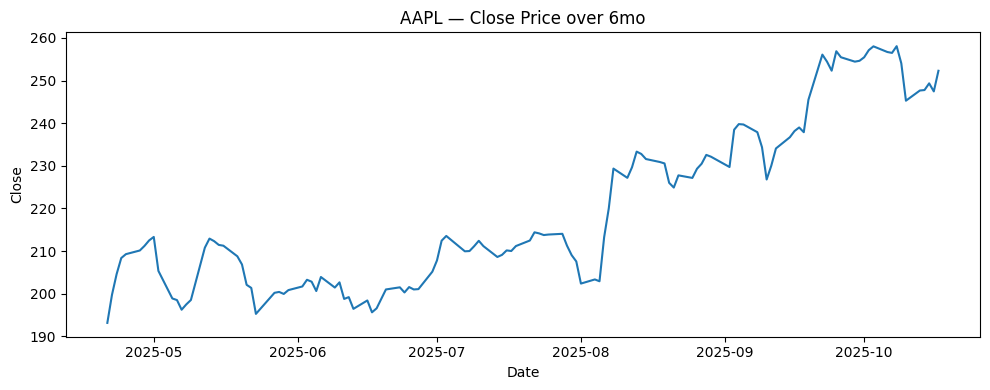

Price window: 2025-04-21 to 2025-10-17  |  Start 193.16  →  End 252.29  |  Change 30.61%


/tmp/ipython-input-1785960414.py:76: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  first = float(prices_plot_df["Close"].iloc[0])
/tmp/ipython-input-1785960414.py:77: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last = float(prices_plot_df["Close"].iloc[-1])


In [47]:
#@title 8.5.1. Plot price series for evaluation
import math
from datetime import timezone
import warnings

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def _tz_naive_index(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """Make DatetimeIndex tz-naive if tz-aware, otherwise return as-is."""
    if getattr(idx, "tz", None) is not None:
        return idx.tz_convert(None)
    return idx

def get_prices_for_plot(ticker_sym: str, period_str: str = "6mo") -> pd.DataFrame:
    """
    Fetches daily Close for the chosen period.
    Uses yfinance with explicit auto_adjust to avoid FutureWarning.
    Returns a DataFrame with ['Date','Close'].
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # keep the output clean
        df = yf.download(
            ticker_sym,
            period=period_str,
            interval="1d",
            progress=False,
            auto_adjust=False,
        )

    if df is None or df.empty:
        return pd.DataFrame(columns=["Date", "Close"])

    df = df.copy()
    # Ensure index is datetime naive for consistent plotting
    if isinstance(df.index, pd.DatetimeIndex):
        df.index = _tz_naive_index(df.index)

    df = df.reset_index()
    # yfinance uses 'Date' or 'Datetime' depending on version
    if "Date" not in df.columns and "Datetime" in df.columns:
        df = df.rename(columns={"Datetime": "Date"})
    # Keep only Date/Close columns if available
    keep_cols = ["Date", "Close"]
    for c in keep_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df[keep_cols].dropna()

# ---- Plot runner ----
try:
    selected_ticker = str(ticker) if "ticker" in globals() else "AAPL"
except Exception:
    selected_ticker = "AAPL"

plot_period = globals().get("SELECTED_PERIOD", "6mo")

prices_plot_df = get_prices_for_plot(selected_ticker, plot_period)

if prices_plot_df.empty:
    print(f"No price data available to plot for {selected_ticker} over period '{plot_period}'.")
else:
    plt.figure(figsize=(10, 4))
    plt.plot(prices_plot_df["Date"], prices_plot_df["Close"])
    plt.title(f"{selected_ticker} — Close Price over {plot_period}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.tight_layout()
    plt.show()

    # Friendly summary aligned with evaluator context
    start_d = prices_plot_df["Date"].min().date()
    end_d = prices_plot_df["Date"].max().date()
    first = float(prices_plot_df["Close"].iloc[0])
    last = float(prices_plot_df["Close"].iloc[-1])
    chg = ((last - first) / first * 100.0) if first else float("nan")
    print(f"Price window: {start_d} to {end_d}  |  Start {first:.2f}  →  End {last:.2f}  |  Change {chg:.2f}%")